# Data Cleaning

In [16]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## Inspection

In [17]:
df = pd.read_csv("data/synthetic_forecast_ready.csv")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (8688, 26)


,timestamp,location_id,meal,year,month,day,hour,minute,day_of_week,week_of_year,is_weekend,hour_frac,hour_sin,hour_cos,month_sin,month_cos,is_holiday,holiday_name,special_event,footfall,footfall_raw,waste_kg,waste_kg_target,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg
0,2025-01-01 00:00:00,B,Closed,2025,1,1,0,0,2,1,0,0.0000,0.0000,1.0000,0.5000,0.8660,1,New Year's Day,NaN,0,0,0.0000,0.0000,0.0000,0.0000,0.0000
1,2025-01-01 00:30:00,D,Closed,2025,1,1,0,30,2,1,0,0.5000,0.0000,1.0000,0.5000,0.8660,1,New Year's Day,NaN,4,4,0.0400,0.0400,0.0200,0.0100,0.0100
2,2025-01-01 01:00:00,D,Closed,2025,1,1,1,0,2,1,0,1.0000,0.2588,0.9659,0.5000,0.8660,1,New Year's Day,NaN,1,1,0.0500,0.0500,0.0200,0.0100,0.0100
3,2025-01-01 01:30:00,B,Closed,2025,1,1,1,30,2,1,0,1.5000,0.2588,0.9659,0.5000,0.8660,1,New Year's Day,NaN,4,4,0.0500,0.0500,0.0200,0.0100,0.0200
4,2025-01-01 02:00:00,D,Closed,2025,1,1,2,0,2,1,0,2.0000,0.5000,0.8660,0.5000,0.8660,1,New Year's Day,NaN,0,0,0.0200,0.0200,0.0100,0.0000,0.0100
5,2025-01-01 02:30:00,D,Closed,2025,1,1,2,30,2,1,0,2.5000,0.5000,0.8660,0.5000,0.8660,1,New Year's Day,NaN,4,4,0.0100,0.0100,0.0000,0.0000,0.0000
6,2025-01-01 03:00:00,C,Closed,2025,1,1,3,0,2,1,0,3.0000,0.7071,0.7071,0.5000,0.8660,1,New Year's Day,NaN,3,3,0.0400,0.0400,0.0200,0.0100,0.0100
7,2025-01-01 03:30:00,D,Closed,2025,1,1,3,30,2,1,0,3.5000,0.7071,0.7071,0.5000,0.8660,1,New Year's Day,NaN,1,1,0.0000,0.0000,0.0000,0.0000,0.0000
8,2025-01-01 04:00:00,D,Closed,2025,1,1,4,0,2,1,0,4.0000,0.8660,0.5000,0.5000,0.8660,1,New Year's Day,NaN,1,1,0.0200,0.0200,0.0100,0.0100,0.0100
9,2025-01-01 04:30:00,D,Closed,2025,1,1,4,30,2,1,0,4.5000,0.8660,0.5000,0.5000,0.8660,1,New Year's Day,NaN,0,0,0.0400,0.0400,0.0200,0.0100,0.0100


In [18]:
print("Column Types")
print(df.dtypes)
print("\nNulls per column")
print(df.isnull().sum())
print("\nDescriptive Stats")
df.describe(include='all')

Column Types
timestamp                  str
location_id                str
meal                       str
year                     int64
month                    int64
day                      int64
hour                     int64
minute                   int64
day_of_week              int64
week_of_year             int64
is_weekend               int64
hour_frac              float64
hour_sin               float64
hour_cos               float64
month_sin              float64
month_cos              float64
is_holiday               int64
holiday_name               str
special_event              str
footfall                 int64
footfall_raw             int64
waste_kg               float64
waste_kg_target        float64
waste_organic_kg       float64
waste_recyclable_kg    float64
waste_landfill_kg      float64
dtype: object

Nulls per column
timestamp                 0
location_id               0
meal                      0
year                      0
month                     0
day      

,timestamp,location_id,meal,year,month,day,hour,minute,day_of_week,week_of_year,is_weekend,hour_frac,hour_sin,hour_cos,month_sin,month_cos,is_holiday,holiday_name,special_event,footfall,footfall_raw,waste_kg,waste_kg_target,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg
count,8688,8688,8688,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,576,672,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000
unique,8688,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2025-01-01 00:00:00,B,Closed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New Year's Day,March Madness Weekend,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2262,4706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2025.0000,3.5083,15.6022,11.5000,15.0000,3.0110,13.7127,0.2873,11.7500,-0.0000,-0.0000,0.6201,-0.1713,0.0663,NaN,NaN,37.7064,36.8351,0.8796,0.8796,0.4769,0.2693,0.1330
std,NaN,NaN,NaN,0.0000,1.7101,8.7358,6.9226,15.0009,2.0001,7.4701,0.4525,6.9271,0.7071,0.7071,0.3358,0.6881,0.2488,NaN,NaN,51.6072,50.6382,1.1520,1.1520,0.6473,0.3708,0.1660
min,NaN,NaN,NaN,2025.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,-1.0000,-1.0000,0.0000,-1.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,NaN,NaN,NaN,2025.0000,2.0000,8.0000,5.7500,0.0000,1.0000,7.0000,0.0000,5.8750,-0.7071,-0.7071,0.5000,-0.8660,0.0000,NaN,NaN,2.0000,2.0000,0.0200,0.0200,0.0100,0.0100,0.0000
50%,NaN,NaN,NaN,2025.0000,4.0000,16.0000,11.5000,15.0000,3.0000,14.0000,0.0000,11.7500,0.0000,-0.0000,0.5000,-0.5000,0.0000,NaN,NaN,5.0000,5.0000,0.0500,0.0500,0.0200,0.0100,0.0100
75%,NaN,NaN,NaN,2025.0000,5.0000,23.0000,17.2500,30.0000,5.0000,20.0000,1.0000,17.6250,0.7071,0.7071,0.8660,0.5000,0.0000,NaN,NaN,65.0000,63.0000,1.5300,1.5300,0.8400,0.4400,0.2400


In [19]:
cat_cols = ['location_id', 'is_weekend', 'is_holiday', 'holiday_name', 'special_event']
for col in cat_cols:
    if col in df.columns:
        print(f"\n[{col}] — {df[col].nunique()} unique values:")
        print(df[col].value_counts(dropna=False).head(20))


[location_id] — 4 unique values:
location_id
B    2262
C    2180
D    2150
A    2096
Name: count, dtype: int64

[is_weekend] — 2 unique values:
is_weekend
0    6192
1    2496
Name: count, dtype: int64

[is_holiday] — 2 unique values:
is_holiday
0    8112
1     576
Name: count, dtype: int64

[holiday_name] — 12 unique values:
holiday_name
NaN                  8112
New Year's Day         48
MLK Day                48
Holiday                48
Valentine's Day        48
Presidents Day         48
St. Patrick's Day      48
Good Friday            48
Easter                 48
Cinco de Mayo          48
Memorial Day           48
Father's Day           48
Juneteenth             48
Name: count, dtype: int64

[special_event] — 11 unique values:
special_event
NaN                         8016
March Madness Weekend         96
Campus Career Fair            96
Memorial Weekend BBQ          96
NFL Playoff Watch Party       48
Super Bowl Watch Party        48
Valentine's Dinner Promo      48
Spring Festiv

In [20]:
print("First 200 rows — scroll to spot formatting issues:")
df.head(200)

First 200 rows — scroll to spot formatting issues:


,timestamp,location_id,meal,year,month,day,hour,minute,day_of_week,week_of_year,is_weekend,hour_frac,hour_sin,hour_cos,month_sin,month_cos,is_holiday,holiday_name,special_event,footfall,footfall_raw,waste_kg,waste_kg_target,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg
0,2025-01-01 00:00:00,B,Closed,2025,1,1,0,0,2,1,0,0.0000,0.0000,1.0000,0.5000,0.8660,1,New Year's Day,NaN,0,0,0.0000,0.0000,0.0000,0.0000,0.0000
1,2025-01-01 00:30:00,D,Closed,2025,1,1,0,30,2,1,0,0.5000,0.0000,1.0000,0.5000,0.8660,1,New Year's Day,NaN,4,4,0.0400,0.0400,0.0200,0.0100,0.0100
2,2025-01-01 01:00:00,D,Closed,2025,1,1,1,0,2,1,0,1.0000,0.2588,0.9659,0.5000,0.8660,1,New Year's Day,NaN,1,1,0.0500,0.0500,0.0200,0.0100,0.0100
3,2025-01-01 01:30:00,B,Closed,2025,1,1,1,30,2,1,0,1.5000,0.2588,0.9659,0.5000,0.8660,1,New Year's Day,NaN,4,4,0.0500,0.0500,0.0200,0.0100,0.0200
4,2025-01-01 02:00:00,D,Closed,2025,1,1,2,0,2,1,0,2.0000,0.5000,0.8660,0.5000,0.8660,1,New Year's Day,NaN,0,0,0.0200,0.0200,0.0100,0.0000,0.0100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2025-01-05 01:30:00,C,Closed,2025,1,5,1,30,6,1,1,1.5000,0.2588,0.9659,0.5000,0.8660,0,NaN,NaN,1,1,0.0000,0.0000,0.0000,0.0000,0.0000
196,2025-01-05 02:00:00,B,Closed,2025,1,5,2,0,6,1,1,2.0000,0.5000,0.8660,0.5000,0.8660,0,NaN,NaN,1,1,0.0400,0.0400,0.0200,0.0100,0.0100
197,2025-01-05 02:30:00,A,Closed,2025,1,5,2,30,6,1,1,2.5000,0.5000,0.8660,0.5000,0.8660,0,NaN,NaN,1,1,0.0200,0.0200,0.0100,0.0000,0.0100
198,2025-01-05 03:00:00,B,Closed,2025,1,5,3,0,6,1,1,3.0000,0.7071,0.7071,0.5000,0.8660,0,NaN,NaN,0,0,0.0300,0.0300,0.0100,0.0100,0.0100


## Handle Missing Values (Without Dropping Rows)

In [21]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'location_id' in df.columns:
    df[numeric_cols] = (
        df.groupby('location_id')[numeric_cols]
        .transform(lambda s: s.interpolate(method='linear', limit_direction='both'))
    )
else:
    df[numeric_cols] = df[numeric_cols].interpolate(
        method='linear', limit_direction='both'
    )

for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  {col}: residual NaNs filled with median")

print("Numerical imputation complete.")

Numerical imputation complete.


In [22]:
cat_fill_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

if 'timestamp' in cat_fill_cols:
    cat_fill_cols.remove('timestamp')

for col in cat_fill_cols:
    if df[col].isnull().any():
        if 'location_id' in df.columns:
            df[col] = (
                df.groupby('location_id')[col]
                .transform(lambda s: s.ffill().bfill())
            )
        else:
            df[col] = df[col].ffill().bfill()

        df[col] = df[col].fillna('Unknown')

        print(f"{col}: forward/back-filled, remaining → 'Unknown'")

print("\nNull check after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

holiday_name: forward/back-filled, remaining → 'Unknown'
special_event: forward/back-filled, remaining → 'Unknown'

Null check after imputation:
Series([], dtype: int64)


## Data Type Correction

In [23]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
bad_timestamps = df['timestamp'].isnull().sum()
if bad_timestamps:
    print(f"WARNING: {bad_timestamps} timestamps failed to parse — inspect these rows.")
    print(df[df['timestamp'].isnull()])

int_cols = ['year', 'month', 'day', 'hour', 'minute',
            'day_of_week', 'week_of_year', 'is_weekend',
            'is_holiday', 'footfall_raw']
for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

float_cols = ['footfall', 'waste_kg', 'waste_kg_target',
              'waste_organic_kg', 'waste_recyclable_kg', 'waste_landfill_kg']
for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['location_id', 'holiday_name', 'special_event']:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("Updated dtypes:")
print(df.dtypes)

Updated dtypes:
timestamp              datetime64[us]
location_id                  category
meal                              str
year                            Int64
month                           Int64
day                             Int64
hour                            Int64
minute                          Int64
day_of_week                     Int64
week_of_year                    Int64
is_weekend                      Int64
hour_frac                     float64
hour_sin                      float64
hour_cos                      float64
month_sin                     float64
month_cos                     float64
is_holiday                      Int64
holiday_name                 category
special_event                category
footfall                        int64
footfall_raw                    Int64
waste_kg                      float64
waste_kg_target               float64
waste_organic_kg              float64
waste_recyclable_kg           float64
waste_landfill_kg             floa

## Outlier Treatment

In [24]:
outlier_log = {}

for col in float_cols:
    if col not in df.columns:
        continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    n_low  = (df[col] < lower).sum()
    n_high = (df[col] > upper).sum()
    
    if n_low + n_high > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        outlier_log[col] = {'lower_cap': round(lower,4),
                             'upper_cap': round(upper,4),
                             'n_capped_low': int(n_low),
                             'n_capped_high': int(n_high)}
        print(f"  {col}: capped {n_low} low, {n_high} high values  [{lower:.3f}, {upper:.3f}]")
    else:
        print(f"  {col}: no outliers detected.")

  footfall: capped 0 low, 11 high values  [-187.000, 254.000]
  waste_kg: no outliers detected.
  waste_kg_target: no outliers detected.
  waste_organic_kg: no outliers detected.
  waste_recyclable_kg: capped 0 low, 37 high values  [-1.280, 1.730]
  waste_landfill_kg: no outliers detected.


## Checks

In [25]:
issues = []

waste_component_cols = ['waste_organic_kg', 'waste_recyclable_kg', 'waste_landfill_kg']
if all(c in df.columns for c in waste_component_cols + ['waste_kg']):
    waste_sum = df[waste_component_cols].sum(axis=1)
    tolerance = 0.05
    mismatch = (abs(waste_sum - df['waste_kg']) > tolerance).sum()
    print(f"Waste component sum mismatch (>{tolerance} kg): {mismatch} rows")
    if mismatch:
        issues.append(f"{mismatch} rows where waste components don't sum to waste_kg")

if 'footfall' in df.columns and 'footfall_raw' in df.columns:
    ff_mismatch = (abs(df['footfall'].astype(float) - df['footfall_raw'].astype(float)) > 1).sum()
    print(f"footfall vs footfall_raw mismatch (>1): {ff_mismatch} rows")
    if ff_mismatch:
        issues.append(f"{ff_mismatch} rows with footfall/footfall_raw discrepancy")

if 'location_id' in df.columns:
    ts_ordered = df.groupby('location_id')['timestamp'].is_monotonic_increasing.all()
    print(f"Timestamps monotonically increasing per location: {ts_ordered}")

dups = df.duplicated(subset=['timestamp', 'location_id']).sum() if 'location_id' in df.columns else df.duplicated().sum()
print(f"Duplicate (timestamp, location_id) pairs: {dups}")
if dups:
    issues.append(f"{dups} duplicate timestamp/location pairs")

for col in ['month', 'day', 'hour', 'minute']:
    if col not in df.columns:
        continue
    valid_ranges = {'month': (1,12), 'day': (1,31), 'hour': (0,23), 'minute': (0,59)}
    lo, hi = valid_ranges[col]
    bad = ((df[col] < lo) | (df[col] > hi)).sum()
    if bad:
        print(f"  {col}: {bad} out-of-range values")
        issues.append(f"{bad} out-of-range values in {col}")

print("\nIssues found:", issues if issues else "None")

Waste component sum mismatch (>0.05 kg): 32 rows
footfall vs footfall_raw mismatch (>1): 314 rows
Timestamps monotonically increasing per location: True
Duplicate (timestamp, location_id) pairs: 0

Issues found: ["32 rows where waste components don't sum to waste_kg", '314 rows with footfall/footfall_raw discrepancy']


## Error Correction

In [26]:
str_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

for col in str_cols:
    original = df[col]
    cleaned = original.astype('string').str.strip().str.lower()
    changed = (original.astype('string') != cleaned).sum()
    if changed:
        print(f"{col}: normalised {changed} values")

    if str(original.dtype) == 'category':
        df[col] = cleaned.astype('category')
    else:
        df[col] = cleaned

non_negative_cols = [
    'footfall', 'footfall_raw', 'waste_kg',
    'waste_organic_kg', 'waste_recyclable_kg', 'waste_landfill_kg'
]

for col in non_negative_cols:
    if col in df.columns:
        neg = (df[col] < 0).sum()
        if neg:
            df[col] = df[col].clip(lower=0)
            print(f"{col}: {neg} negative values clipped to 0")

print("Error correction complete.")

location_id: normalised 8688 values
meal: normalised 8688 values
holiday_name: normalised 8688 values
special_event: normalised 8688 values
Error correction complete.


## Validation

In [27]:
print("Summary Stats key columns")
cols_to_check = [c for c in float_cols if c in df.columns]
print(df[cols_to_check].describe().round(4))

Summary Stats key columns
       footfall  waste_kg  waste_kg_target  waste_organic_kg  \
count 8688.0000 8688.0000        8688.0000         8688.0000   
mean    37.6865    0.8796           0.8796            0.4769   
std     51.5191    1.1520           1.1520            0.6473   
min      0.0000    0.0000           0.0000            0.0000   
25%      2.0000    0.0200           0.0200            0.0100   
50%      5.0000    0.0500           0.0500            0.0200   
75%     65.0000    1.5300           1.5300            0.8400   
max    254.0000    6.0000           6.0000            3.3100   

       waste_recyclable_kg  waste_landfill_kg  
count            8688.0000          8688.0000  
mean                0.2687             0.1330  
std                 0.3680             0.1660  
min                 0.0000             0.0000  
25%                 0.0100             0.0000  
50%                 0.0100             0.0100  
75%                 0.4400             0.2400  
max          

In [28]:
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls) == 0:
    print("No remaining nulls in dataset.")
else:
    print("Remaining nulls:")
    print(remaining_nulls)

No remaining nulls in dataset.


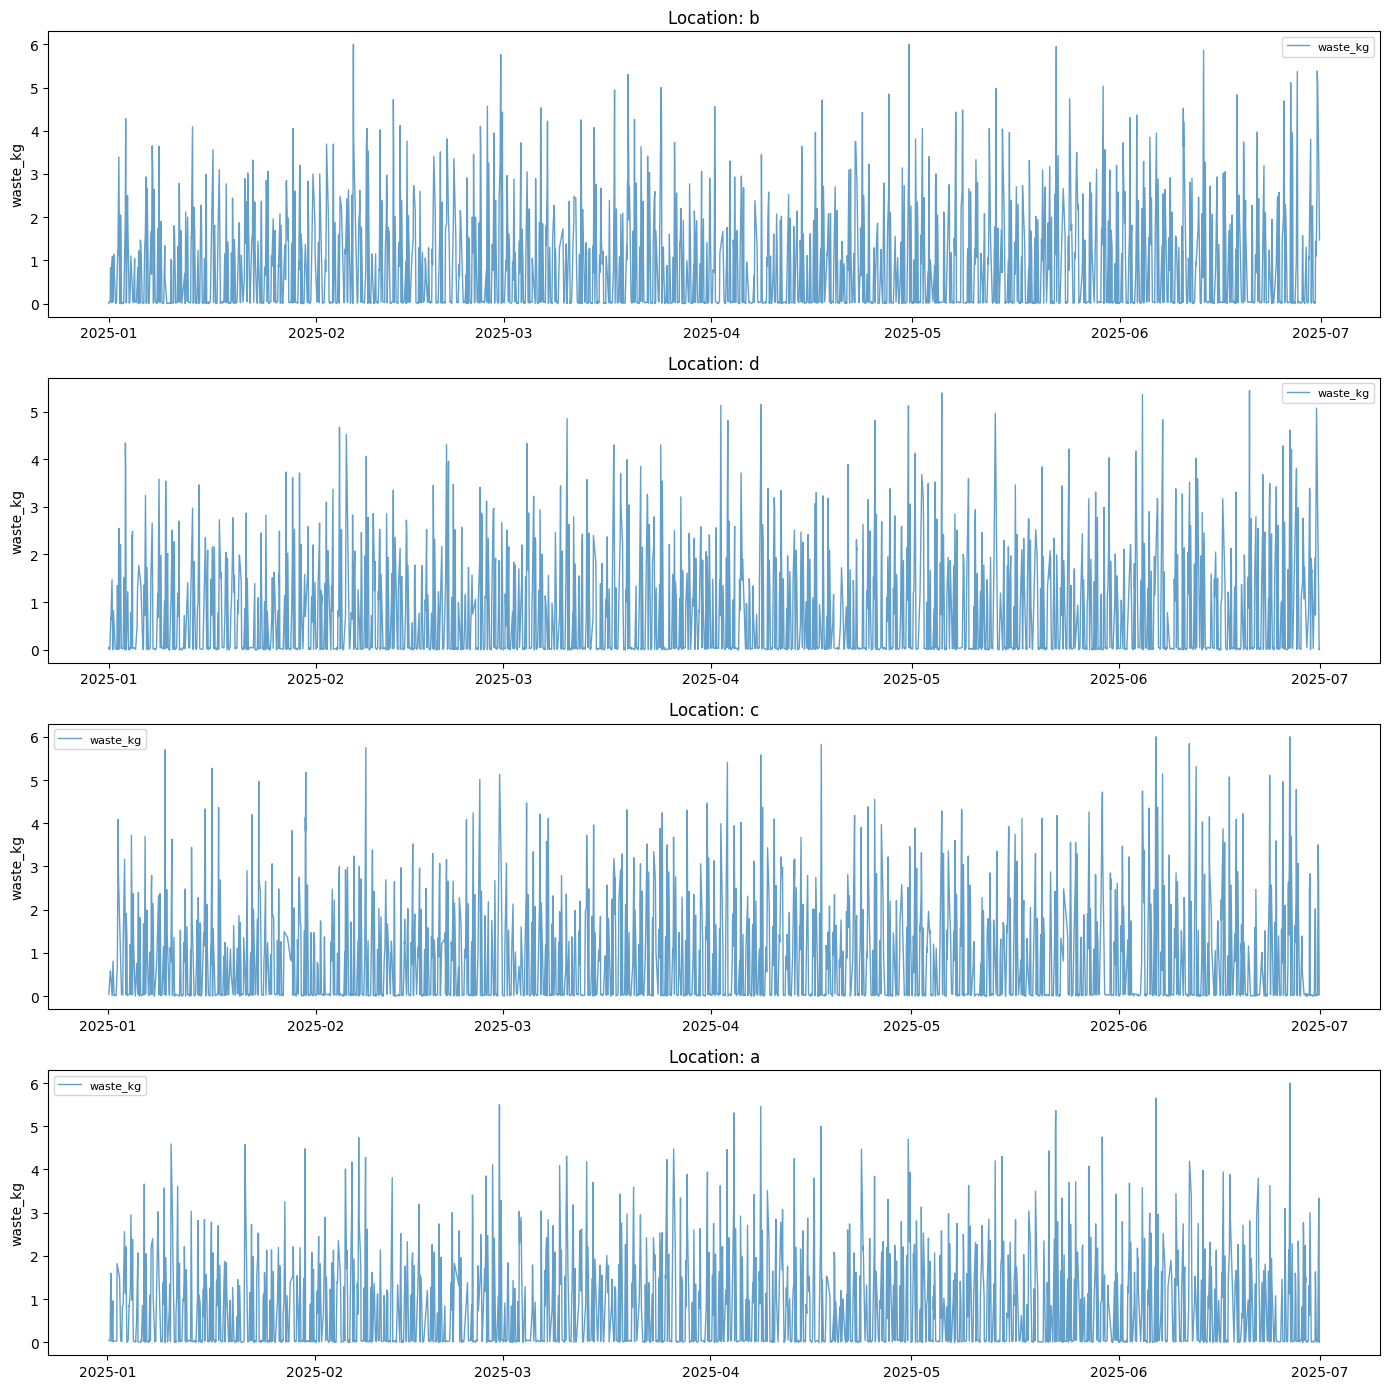

In [29]:
locations = df['location_id'].unique()[:4]
fig, axes = plt.subplots(len(locations), 1, figsize=(14, 3.5 * len(locations)), sharex=False)
if len(locations) == 1:
    axes = [axes]

for ax, loc in zip(axes, locations):
    sub = df[df['location_id'] == loc].sort_values('timestamp')
    ax.plot(sub['timestamp'], sub['waste_kg'], label='waste_kg', lw=1, alpha=0.7)
    ax.set_title(f"Location: {loc}")
    ax.set_ylabel("waste_kg")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Save

In [30]:
output_path = "data/synthetic_forecast_cleaned.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved → {output_path}")
df.head()

Cleaned dataset saved → data/synthetic_forecast_cleaned.csv


,timestamp,location_id,meal,year,month,day,hour,minute,day_of_week,week_of_year,is_weekend,hour_frac,hour_sin,hour_cos,month_sin,month_cos,is_holiday,holiday_name,special_event,footfall,footfall_raw,waste_kg,waste_kg_target,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg
0,2025-01-01 00:00:00,b,closed,2025,1,1,0,0,2,1,0,0.0000,0.0000,1.0000,0.5000,0.8660,1,new year's day,nfl playoff watch party,0,0,0.0000,0.0000,0.0000,0.0000,0.0000
1,2025-01-01 00:30:00,d,closed,2025,1,1,0,30,2,1,0,0.5000,0.0000,1.0000,0.5000,0.8660,1,new year's day,nfl playoff watch party,4,4,0.0400,0.0400,0.0200,0.0100,0.0100
2,2025-01-01 01:00:00,d,closed,2025,1,1,1,0,2,1,0,1.0000,0.2588,0.9659,0.5000,0.8660,1,new year's day,nfl playoff watch party,1,1,0.0500,0.0500,0.0200,0.0100,0.0100
3,2025-01-01 01:30:00,b,closed,2025,1,1,1,30,2,1,0,1.5000,0.2588,0.9659,0.5000,0.8660,1,new year's day,nfl playoff watch party,4,4,0.0500,0.0500,0.0200,0.0100,0.0200
4,2025-01-01 02:00:00,d,closed,2025,1,1,2,0,2,1,0,2.0000,0.5000,0.8660,0.5000,0.8660,1,new year's day,nfl playoff watch party,0,0,0.0200,0.0200,0.0100,0.0000,0.0100
